In [1]:
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import numpy as np

df_model = pd.read_csv("employee_attrition_clean.csv")

df_model.head()

,job_level,department,tenure_months,salary,satisfaction_score,workload_score,team_sentiment,project_completion_rate,overtime_hours,training_participation,...,email_sentiment,goal_achievement_rate,stress_level,left_company,role_complexity_score,career_progression_score,feedback_sentiment,underpaid_overtime,burnout_indicator_score,new_employee
0,Mid,R&D,169,79704.579059,0.623746,0.758117,0.662335,0.524187,0.00000,0.044373,...,0.632891,0.632482,0.908992,False,0.2,1.000000,0.7351,False,1.043363,False
1,Manager,R&D,54,29694.288831,0.982556,0.788416,0.934661,0.558206,0.00000,0.314858,...,1.000000,0.538587,0.363321,False,0.2,1.000000,0.9509,False,0.169181,False
2,Entry,HR,1,62208.470185,0.767200,0.697617,0.888559,0.566849,0.00000,0.744900,...,0.758005,0.624656,0.664378,True,0.2,0.836495,0.8999,False,0.594795,True
3,Manager,R&D,31,236066.567114,0.185888,0.493143,0.732189,0.767456,9.59168,0.298170,...,0.202517,0.959320,1.000000,False,0.2,1.000000,0.7184,False,1.307255,False
4,Mid,R&D,131,37306.328156,0.566706,0.567230,0.817545,0.597235,0.00000,0.134719,...,0.559722,0.677305,0.723049,False,0.2,1.000000,-0.3404,False,0.723572,False


In [2]:
df_model.shape

(849999, 21)

In [3]:
df_model.dtypes

job_level                       str
department                      str
tenure_months                 int64
salary                      float64
satisfaction_score          float64
workload_score              float64
team_sentiment              float64
project_completion_rate     float64
overtime_hours              float64
training_participation      float64
collaboration_score         float64
email_sentiment             float64
goal_achievement_rate       float64
stress_level                float64
left_company                   bool
role_complexity_score       float64
career_progression_score    float64
feedback_sentiment          float64
underpaid_overtime             bool
burnout_indicator_score     float64
new_employee                   bool
dtype: object

In [4]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 849999 entries, 0 to 849998
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   job_level                 849999 non-null  str    
 1   department                849999 non-null  str    
 2   tenure_months             849999 non-null  int64  
 3   salary                    849999 non-null  float64
 4   satisfaction_score        849999 non-null  float64
 5   workload_score            849999 non-null  float64
 6   team_sentiment            849999 non-null  float64
 7   project_completion_rate   849999 non-null  float64
 8   overtime_hours            849999 non-null  float64
 9   training_participation    849999 non-null  float64
 10  collaboration_score       849999 non-null  float64
 11  email_sentiment           849999 non-null  float64
 12  goal_achievement_rate     849999 non-null  float64
 13  stress_level              849999 non-null  float64
 14 

In [5]:
# Split off predictor variabels from target

X = df_model.drop("left_company", axis=1)
y = df_model["left_company"]

In [6]:
X.shape

(849999, 20)

In [7]:
# Split data into train and test splits

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(679999, 20)
(170000, 20)


In [8]:
cat_features = ["job_level", "department"]
bool_features = ["underpaid_overtime", "new_employee"]
num_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(num_features)
print(cat_features)
print(bool_features)

['tenure_months', 'salary', 'satisfaction_score', 'workload_score', 'team_sentiment', 'project_completion_rate', 'overtime_hours', 'training_participation', 'collaboration_score', 'email_sentiment', 'goal_achievement_rate', 'stress_level', 'role_complexity_score', 'career_progression_score', 'feedback_sentiment', 'burnout_indicator_score']
['job_level', 'department']
['underpaid_overtime', 'new_employee']


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("scaler", StandardScaler()),
])
dept_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
job_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder(categories=[["Entry", "Mid", "Senior", "Lead", "Manager"]]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("dep", dept_pipeline, ["department"]),
        ("job", job_pipeline, ["job_level"]),
        ("bool", "passthrough", bool_features)
    ]
)




The cell above gets each predictor variable in a proper format for the modeling to come.

## Logistic Regression

In [10]:
# Build the pipeline and fit the model

from sklearn.linear_model import LogisticRegression

log_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42))
])

log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [11]:
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log, zero_division=0)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
roc_auc = roc_auc_score(y_test, y_prob_log)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.7146764705882352
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.5804361232575477


In [13]:

print(pd.Series(y_pred_log).value_counts())

print(y_test.value_counts())

False    170000
Name: count, dtype: int64
left_company
False    121495
True      48505
Name: count, dtype: int64


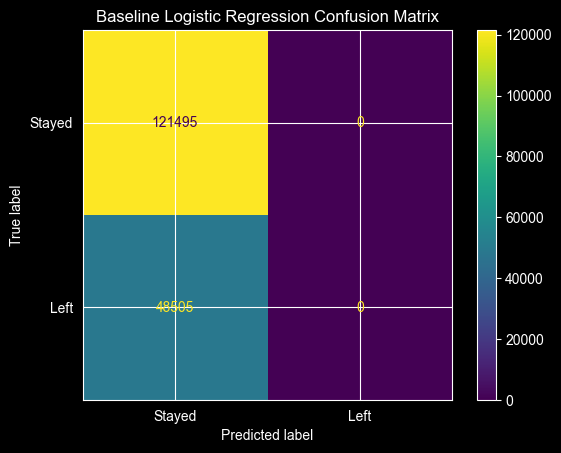

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Baseline Logistic Regression Confusion Matrix")
plt.show()

In [15]:
# Test with balanced class weights

log_reg_balanced = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            random_state=42
        )
    )
])

log_reg_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [16]:
# Predict on test set

y_pred_balanced = log_reg_balanced.predict(X_test)

y_prob_balanced = log_reg_balanced.predict_proba(X_test)[:, 1]

In [17]:
# Test again on all metrics

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)

print(f"Accuracy: {accuracy_balanced}")
print(f"Precision: {precision_balanced}")
print(f"Recall: {recall_balanced}")
print(f"F1: {f1_balanced}")
print(f"ROC AUC: {roc_auc_balanced}")

Accuracy: 0.5221176470588236
Precision: 0.32887239270217994
Recall: 0.6484898464075869
F1: 0.436420395421436
ROC AUC: 0.5804386180332415


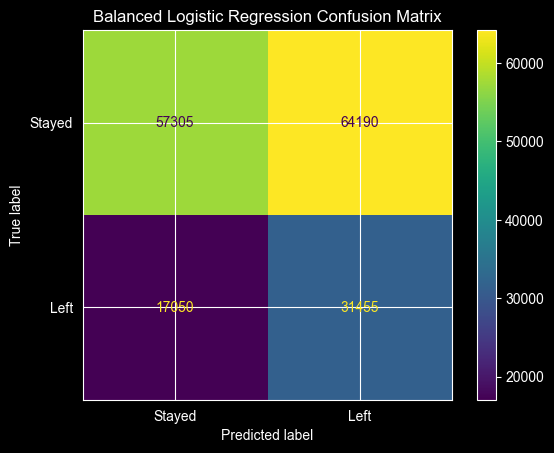

In [18]:
cm = confusion_matrix(y_test, y_pred_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.show()

### Logistic Regression Results

The baseline logistic regression model gave us an accuracy of 71.47%, however that is exactly the percent of the target variable that was flagged as stayed. When looking at the confusion matrix we see that the model predicted that every single person would stay, so none went over the probability threshold needed to predict the employee of leaving.
I created a second logistic regression model that used a "balanced" class to make the model care more about wrongly classifying potential leavers. This updated the model to give outcomes that are more realistic. It gave us a recall of ~65% meaning it correctly identified ~65% of actual leavers, which is much better than zero! However the precision was at ~33% which means there was many people wrongly classified as leavers.
The ROC-AUC score was around 58% which is still fairly weak.

## Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [20]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [21]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, zero_division=0)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.7134882352941176
Precision: 0.3421875
Recall: 0.004514998453767653
F1: 0.008912402075490895
ROC AUC: 0.5536707703551973


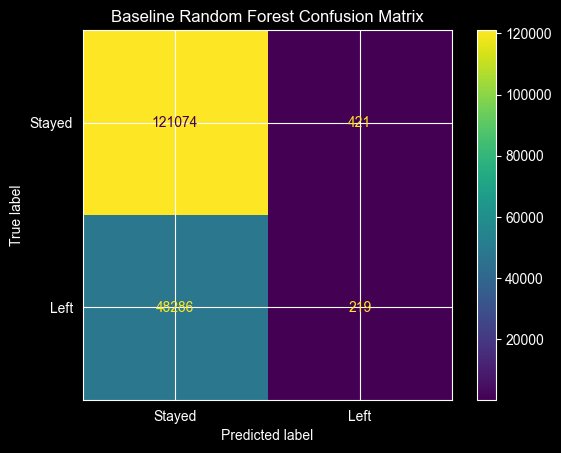

In [22]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Baseline Random Forest Confusion Matrix")
plt.show()

In [23]:
rf_model_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"))
])

rf_model_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[bool](2,)","[False, True]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [24]:
y_pred_rf = rf_model_balanced.predict(X_test)
y_prob_rf = rf_model_balanced.predict_proba(X_test)[:, 1]

In [25]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, zero_division=0)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.6808235294117647
Precision: 0.33811533052039383
Recall: 0.12390475208741367
F1: 0.18135184067592033
ROC AUC: 0.5577347285677214


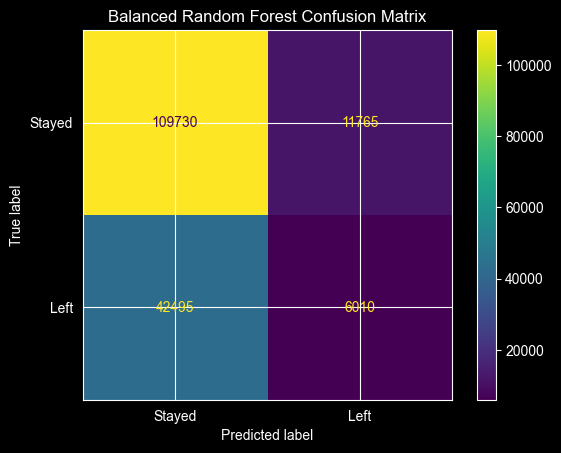

In [26]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Balanced Random Forest Confusion Matrix")
plt.show()

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_rf = {
    "model__n_estimators": [50, 100,200],
    "model__max_depth": [5, 10, 15],
    "model__min_samples_leaf": [1, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": ["balanced"]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_rf,
    cv=5,
    n_iter=10,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
)

In [28]:
random_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced'], 'model__criterion': ['gini', 'entropy'], 'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearch

In [29]:
print(random_search_rf.best_params_)
print(random_search_rf.best_score_)

{'model__n_estimators': 50, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_depth': 10, 'model__criterion': 'gini', 'model__class_weight': 'balanced'}
0.43230053210158276


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

tuned_rf = random_search_rf.best_estimator_

y_pred_tuned_rf = tuned_rf.predict(X_test)
y_prob_tuned_rf = tuned_rf.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_tuned_rf)
precision = precision_score(y_test, y_pred_tuned_rf, zero_division=0)
recall = recall_score(y_test, y_pred_tuned_rf)
f1 = f1_score(y_test, y_pred_tuned_rf)
roc_auc = roc_auc_score(y_test, y_prob_tuned_rf)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5296823529411765
Precision: 0.330256808834483
Recall: 0.6307390990619524
F1: 0.4335208513412025
ROC AUC: 0.5798979994446825


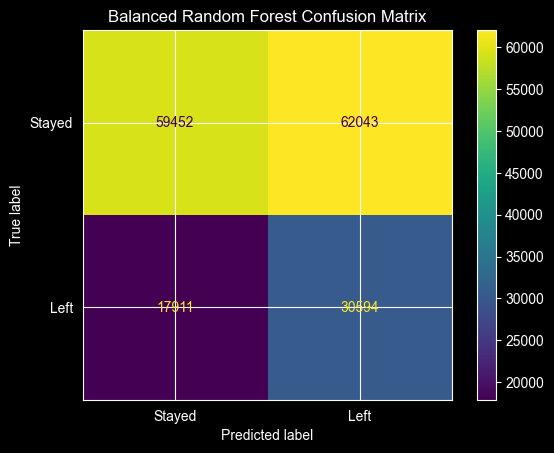

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_tuned_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Balanced Random Forest Confusion Matrix")
plt.show()

In [32]:
features = tuned_rf.named_steps["preprocessor"].get_feature_names_out()
importance = tuned_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({"feature": features, "importance": importance})
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)
feature_importance_df.head(10)

,feature,importance
11,num__stress_level,0.193382
15,num__burnout_indicator_score,0.156895
9,num__email_sentiment,0.147152
2,num__satisfaction_score,0.136221
8,num__collaboration_score,0.070660
3,num__workload_score,0.042088
5,num__project_completion_rate,0.039509
14,num__feedback_sentiment,0.038987
4,num__team_sentiment,0.025163
6,num__overtime_hours,0.024727


<BarContainer object of 35 artists>

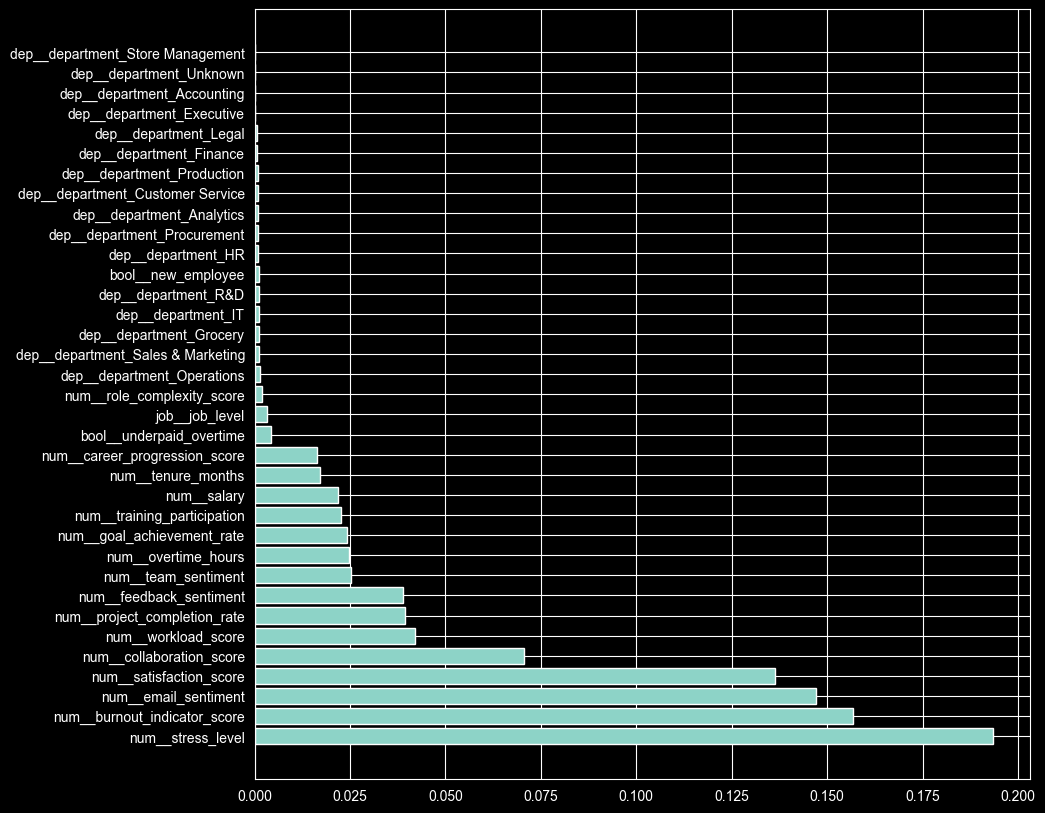

In [33]:
top_features = feature_importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(top_features["feature"], top_features["importance"])

Text(0.5, 1.0, 'Random Forest Feature Importances')

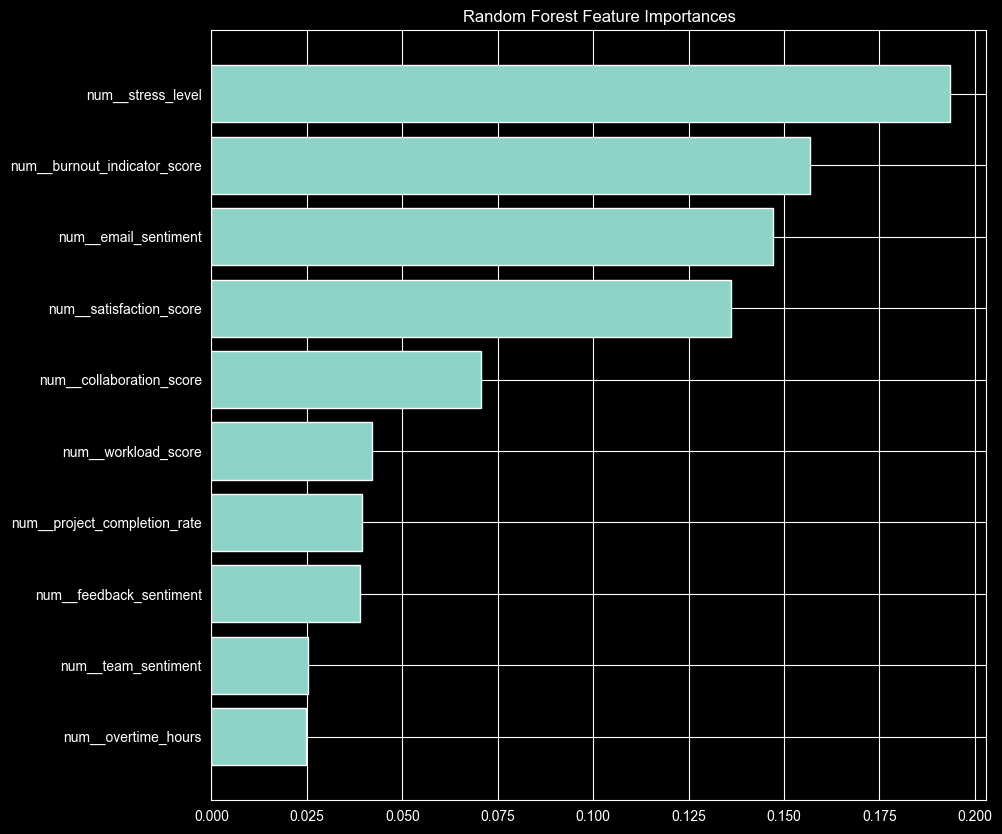

In [34]:
top_10_features = feature_importance_df.sort_values("importance", ascending=True).tail(10)

plt.figure(figsize=(10, 10))
plt.barh(top_10_features["feature"], top_10_features["importance"])
plt.title("Random Forest Feature Importances")


## Random Forest Results

Baseline model once again predicted almost all people as staying. I quickly went to a balanced model and found that performed better than baseline, but worse than our logistic regression model. I did some hyperparameter tuning on the random forest model and found that we were able to achieve very similar results to the balanced logistic regression model. We also plotted the variable the model found most important above.

## XGBOOST

In [35]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    ))
])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [36]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, zero_division=0)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.7143588235294117
Precision: 0.37383177570093457
Recall: 0.0016493145036594165
F1: 0.003284139658038958
ROC AUC: 0.5729492512573964


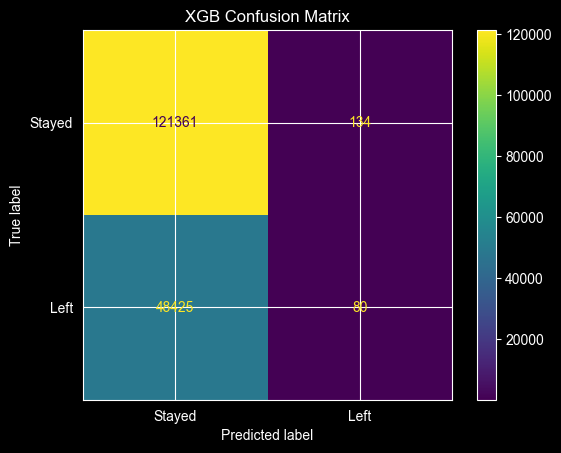

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("XGB Confusion Matrix")
plt.show()

In [39]:
neg = (y_train == False).sum()
pos = (y_train == True).sum()

scale_pos_weight = neg/pos

xgb_model_balanced = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    ))
])

xgb_model_balanced.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [40]:
y_pred_xgb_balanced = xgb_model_balanced.predict(X_test)
y_prob_xgb_balanced = xgb_model_balanced.predict_proba(X_test)[:, 1]

In [41]:
accuracy = accuracy_score(y_test, y_pred_xgb_balanced)
precision = precision_score(y_test, y_pred_xgb_balanced, zero_division=0)
recall = recall_score(y_test, y_pred_xgb_balanced)
f1 = f1_score(y_test, y_pred_xgb_balanced)
roc_auc = roc_auc_score(y_test, y_prob_xgb_balanced)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5298470588235294
Precision: 0.3266618855850389
Recall: 0.6103906813730543
F1: 0.42557136696852094
ROC AUC: 0.572246665864516


In [42]:
from sklearn.model_selection import RandomizedSearchCV
param_xgb = {
    "model__n_estimators": [100,200, 300],
    "model__max_depth": [3, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 2, 3],
    "model__scale_pos_weight": [1, scale_pos_weight]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model_balanced,
    param_distributions=param_xgb,
    cv=5,
    n_iter=10,
    n_jobs=-1,
    scoring="f1",
    random_state=42,
    verbose=2,
)

random_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be 

In [43]:
print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)

{'model__subsample': 1.0, 'model__scale_pos_weight': np.float64(2.5047701022054314), 'model__n_estimators': 300, 'model__min_child_weight': 2, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}
0.4369969997636007


In [44]:
tuned_xgb = random_search_xgb.best_estimator_

y_pred_tuned_xgb = tuned_xgb.predict(X_test)
y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_tuned_xgb)
precision = precision_score(y_test, y_pred_tuned_xgb, zero_division=0)
recall = recall_score(y_test, y_pred_tuned_xgb)
f1 = f1_score(y_test, y_pred_tuned_xgb)
roc_auc = roc_auc_score(y_test, y_prob_tuned_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5176764705882353
Precision: 0.32833388009513653
Recall: 0.6602824451087517
F1: 0.4385788331313463
ROC AUC: 0.580544575494219


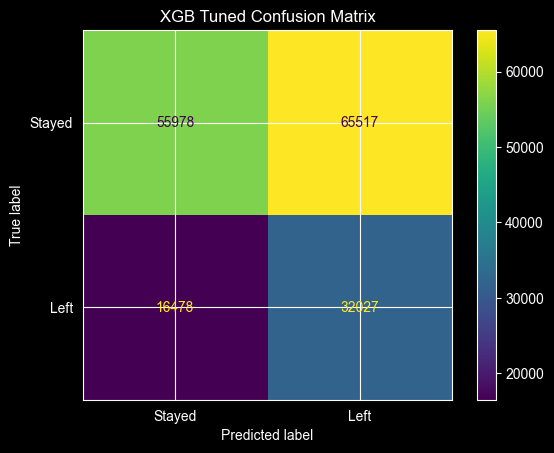

In [45]:
cm = confusion_matrix(y_test, y_pred_tuned_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("XGB Tuned Confusion Matrix")
plt.show()

In [46]:
feature = tuned_xgb.named_steps["preprocessor"].get_feature_names_out()
importance = tuned_xgb.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({"feature": feature, "importance": importance})
feature_importance_df = feature_importance_df.sort_values("importance", ascending=False)
feature_importance_df.head(10)

,feature,importance
11,num__stress_level,0.416428
15,num__burnout_indicator_score,0.222982
2,num__satisfaction_score,0.086295
9,num__email_sentiment,0.077342
3,num__workload_score,0.062788
6,num__overtime_hours,0.042802
8,num__collaboration_score,0.008104
22,dep__department_HR,0.007749
17,dep__department_Analytics,0.007489
0,num__tenure_months,0.006939


<BarContainer object of 35 artists>

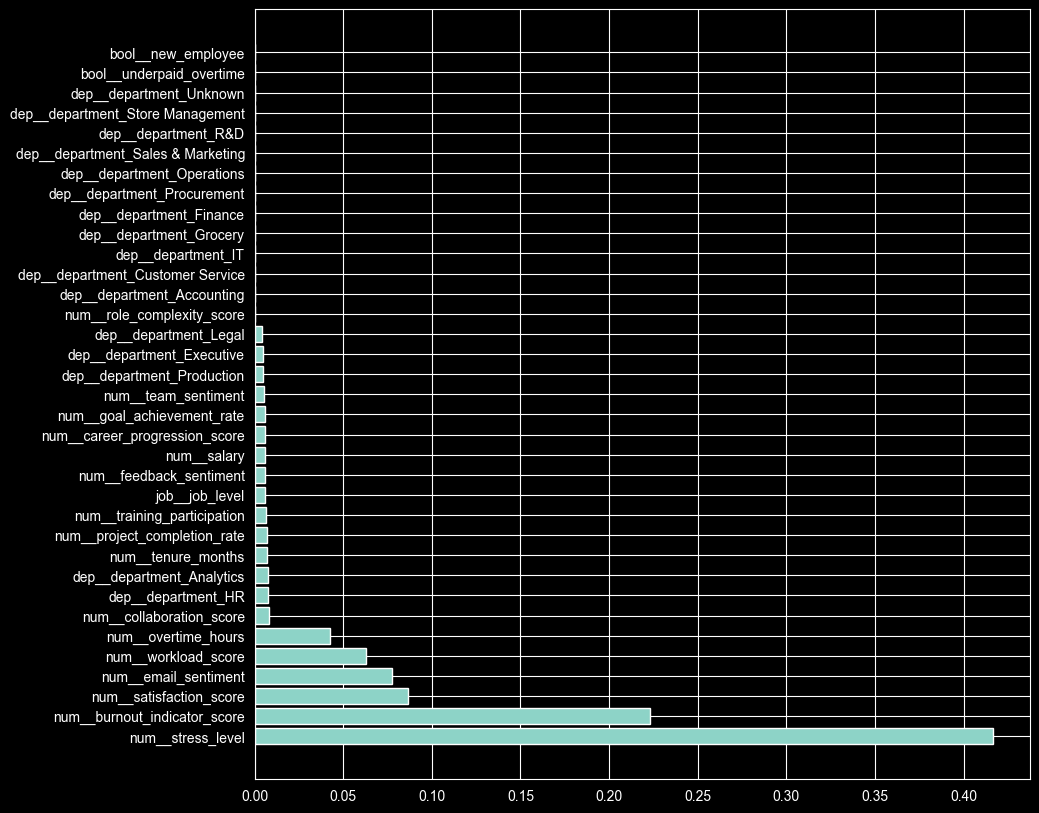

In [47]:
top_features = feature_importance_df.sort_values("importance", ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(top_features["feature"], top_features["importance"])

Text(0.5, 1.0, 'XGBoost Feature Importances')

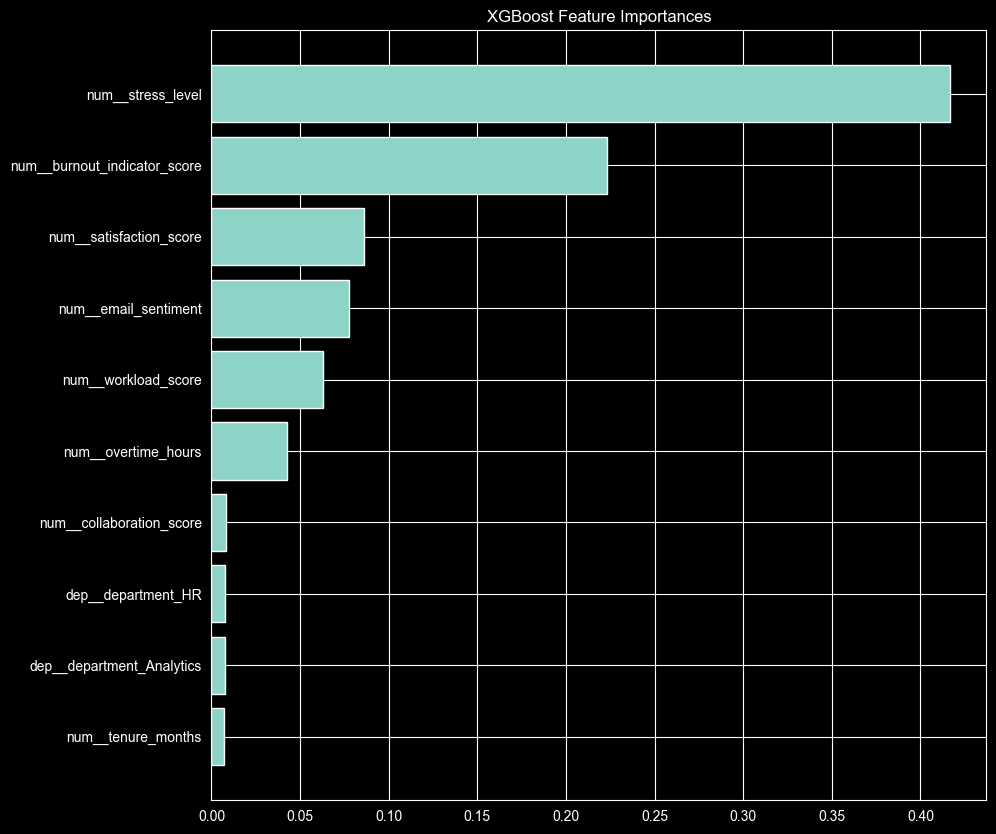

In [48]:
top_10_features = feature_importance_df.sort_values("importance", ascending=True).tail(10)

plt.figure(figsize=(10, 10))
plt.barh(top_10_features["feature"], top_10_features["importance"])
plt.title("XGBoost Feature Importances")

## XGBOOST Results

XGBoost went along the lines of the previous models and did not make significant improvements. We see that there is slightly different feature importance versus random forest, with stress level being by far the most important to the model.

## SMOTE Attempt

In [49]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_xgb = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(
        sampling_strategy="auto",
        random_state=42,
        k_neighbors=5,
    )),
    ("model", XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss",
        subsample=1.0,
        colsample_bytree=0.8,
        learning_rate=0.01,
        max_depth=3,
        min_child_weight=2,
        n_estimators=300,
    )),
])

smote_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](20,)","['job_level','department','tenure_months',...,'underpaid_overtime', 'burnout_indicator_score','new_employee']"
n_features_in_,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('dep', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [50]:
y_pred_smote_xgb = smote_xgb.predict(X_test)
y_prob_smote_xgb = smote_xgb.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred_smote_xgb)
precision = precision_score(y_test, y_pred_smote_xgb, zero_division=0)
recall = recall_score(y_test, y_pred_smote_xgb)
f1 = f1_score(y_test, y_pred_smote_xgb)
roc_auc = roc_auc_score(y_test, y_prob_smote_xgb)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.5541235294117647
Precision: 0.3286155623649972
Recall: 0.5394701577156994
F1: 0.4084349855228552
ROC AUC: 0.5658065229755678


## Smote Results
Its seems that smote is actually a bit worse off than just using weighted impact penalties like in class_weight = balanced in the models.

## Changing Threshold

We will try and see if changing the classification threshold will improve metrics for our best XGBoost model.

In [51]:
y_prob_tuned_xgb = tuned_xgb.predict_proba(X_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    y_pred_threshold = (
        y_prob_tuned_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_pred_threshold
        ),
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.285324,0.285324,1.000000,0.443972
1,0.15,0.285324,0.285324,1.000000,0.443972
2,0.20,0.285324,0.285324,1.000000,0.443972
3,0.25,0.285324,0.285324,1.000000,0.443972
4,0.30,0.285324,0.285324,1.000000,0.443972
5,0.35,0.285671,0.285392,0.999753,0.444030
6,0.40,0.370241,0.300576,0.909741,0.451859
7,0.45,0.446371,0.314664,0.798268,0.451395
8,0.50,0.517676,0.328334,0.660282,0.438579
9,0.55,0.632524,0.352149,0.342892,0.347459


In [52]:
threshold_40 = 0.40

y_pred_40 = (y_prob_tuned_xgb >= threshold_40).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_40))
print("Precision:", precision_score(y_test, y_pred_40))
print("Recall:", recall_score(y_test, y_pred_40))
print("F1:", f1_score(y_test, y_pred_40))
print("ROC AUC:", roc_auc_score(y_test, y_prob_tuned_xgb))

Accuracy: 0.37024117647058824
Precision: 0.30057626287395783
Recall: 0.9097412637872384
F1: 0.4518593232401325
ROC AUC: 0.580544575494219


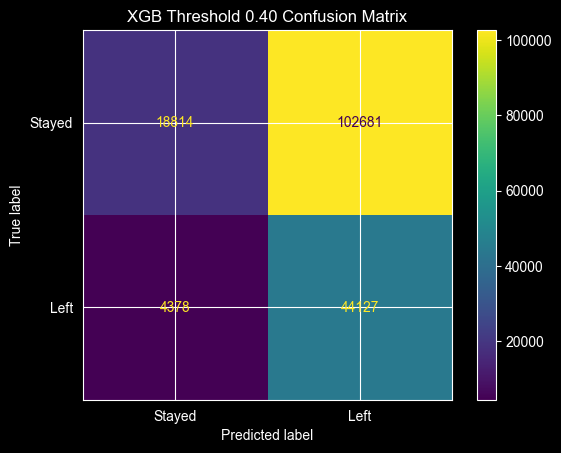

In [53]:
cm = confusion_matrix(y_test, y_pred_40)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot(values_format="d")
plt.title("XGB Threshold 0.40 Confusion Matrix")
plt.show()

In [54]:
threshold_40 = 0.45

y_pred_45 = (y_prob_tuned_xgb >= threshold_40).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_40))
print("Precision:", precision_score(y_test, y_pred_40))
print("Recall:", recall_score(y_test, y_pred_40))
print("F1:", f1_score(y_test, y_pred_40))
print("ROC AUC:", roc_auc_score(y_test, y_prob_tuned_xgb))

Accuracy: 0.37024117647058824
Precision: 0.30057626287395783
Recall: 0.9097412637872384
F1: 0.4518593232401325
ROC AUC: 0.580544575494219


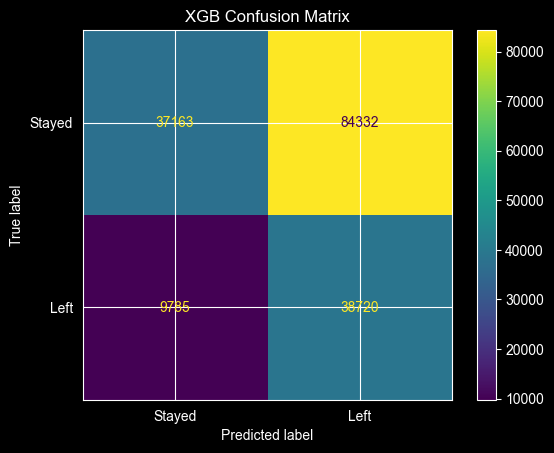

In [55]:
cm = confusion_matrix(y_test, y_pred_45)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("XGB Confusion Matrix")
plt.show()

## Threshold Change Results

It appears that if we lower the bar for the threshold to put someone into the leaving category, we are able to bring recall all the way up to almost 91%! Now this does come at the cost of creating many false positives, but this is interesting finding based on what the business objective would be. If HR would be willing to have many false positives if it meant being able to catch a higher percentage of potential leavers, then this would be of great benefit!

In [56]:
supervised_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Tuned Random Forest",
        "Tuned XGBoost",
        "XGBoost Smote",
        "XGBoost Threshold 0.40"
    ],

    "Accuracy": [
        0.715,
        0.522,
        0.530,
        0.518,
        0.554,
        0.370,

    ],
    "Precision": [
        0.000,
        0.329,
        0.330,
        0.328,
        0.329,
        0.301
    ],
    "Recall": [
        0.000,
        0.648,
        0.631,
        0.660,
        0.539,
        0.910

    ],
    "F1": [
        0.000,
        0.436,
        0.434,
        0.439,
        0.408,
        0.452
    ],
    "ROC AUC": [
        0.580,
        0.580,
        0.580,
        0.581,
        0.566,
        0.581
    ]
})

supervised_results

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.715,0.000,0.000,0.000,0.580
1,Balanced Logistic Regression,0.522,0.329,0.648,0.436,0.580
2,Tuned Random Forest,0.530,0.330,0.631,0.434,0.580
3,Tuned XGBoost,0.518,0.328,0.660,0.439,0.581
4,XGBoost Smote,0.554,0.329,0.539,0.408,0.566
5,XGBoost Threshold 0.40,0.370,0.301,0.910,0.452,0.581
